# Clase 6 — ML en finanzas

**"Finanzas Cuantitativas, la Ciencia y los Mercados"** · FCEN-UBA · Guido Schifani



| Ejercicio | Pregunta que responde |
|---|---|
| **1**  | ¿Qué le estamos pidiendo al modelo que prediga? |
| **2** | Seis modelos (de lo simple a lo más complejo) compiten con la MISMA pregunta. ¿Gana el más potente? |
| **3** | ¿Las técnicas de López de Prado mejoran al modelo, o la validación honesta ya lo neutralizaba todo? |

> 
> 
> Vamos a predecir un evento BINARIO: si un trade que ya se
> abrió va a terminar ganando o perdiendo. 

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')  # evita un deadlock de OpenMP (torch vs. xgboost/lightgbm) en Mac
os.environ.setdefault('OMP_NUM_THREADS', '1')

import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    HAY_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAY_XGB = False

NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED = '#2E7D32', '#C62828'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})
print(f'Listo. XGBoost {"disponible" if HAY_XGB else "NO disponible (uso GradientBoosting de sklearn)"}.')

Listo. XGBoost disponible.


---
## Parte A · Armemos el problema

Regla simple: **comprar SPY cuando el promedio de 20 días está por encima
del de 100 días** (una señal de tendencia de manual, ni buena ni mala — es solo el "primario",
el que decide CUÁNDO entrar). La pregunta de esta práctica NO es si esa regla es buena. La
pregunta es: **una vez que la regla dice "entrá", ¿podemos predecir si ese trade en particular
va a salir bien?**

Para eso necesitamos, primero, una forma de decir "salió bien" o "salió mal" para cada trade
histórico. Eso es la **triple barrera**.

In [2]:
# ── Datos: SPY diario, con respaldo sintético si Yahoo falla ──────────────────
try:
    spy = yf.download('SPY', period='10y', progress=False)['Close'].dropna().squeeze()
    fuente = f'SPY en vivo ({len(spy)} días)'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(2)
    n = 2500; s2 = np.zeros(n); eps = np.zeros(n); s2[0] = 1e-4
    for t in range(1, n):
        s2[t] = 2e-6 + 0.1*eps[t-1]**2 + 0.88*s2[t-1]
        eps[t] = np.sqrt(s2[t])*rng.standard_normal()
    spy = pd.Series(400*np.exp(np.cumsum(0.0003 + eps)), index=pd.date_range('2016-07-01', periods=n, freq='B'))

r = np.log(spy/spy.shift(1)).dropna()               # retornos diarios (log)
sigma = r.ewm(span=20).std()                          # volatilidad reciente: el ANCHO de las barreras

sma20, sma100 = spy.rolling(20).mean(), spy.rolling(100).mean()
senal = (sma20 > sma100).astype(int)                  # el "primario": 1 = comprado
dias_senal = senal[senal == 1].index.intersection(sigma.dropna().index)
print(f'[{fuente}] | el primario está comprado el {senal.mean()*100:.0f}% del tiempo')

[SPY en vivo (2513 días)] | el primario está comprado el 77% del tiempo


**La triple barrera:** el día que el primario dice "entrá", trazamos DOS líneas
horizontales alrededor del precio de entrada: una arriba (a +2 desvíos estándar) y una abajo
(a −2 desvíos estándar). Miramos los próximos 10 días. Si el precio toca la de arriba primero,
el trade "gana" (etiqueta = 1). Si toca la de abajo primero, "pierde" (etiqueta = 0). Si pasan
los 10 días sin tocar ninguna, se cierra igual y el signo del retorno decide.

**Eso — 1 o 0 — es TODO lo que los modelos de hoy van a tratar de predecir.** No un precio, no
un porcentaje de retorno: un evento binario, con una fecha de inicio y una fecha de fin.

In [3]:
def triple_barrera(precios, fecha, sigma_t, k=2.0, max_dias=10):
    """Etiqueta el trade iniciado en `fecha`: 1 si toca +k·σ primero, 0 si toca −k·σ, y el signo
    del retorno si expira sin tocar ninguna. Devuelve también CUÁNDO se resolvió y POR QUÉ."""
    p0 = precios.loc[fecha]
    ventana = precios.loc[fecha:].iloc[1:max_dias+1]
    sup, inf = p0*(1 + k*sigma_t), p0*(1 - k*sigma_t)
    for fecha_fin, precio in ventana.items():
        if precio >= sup: return 1, fecha_fin, 'tp'            # take-profit
        if precio <= inf: return 0, fecha_fin, 'sl'             # stop-loss
    if len(ventana) == 0:
        return None, None, None
    return int(ventana.iloc[-1] > p0), ventana.index[-1], 'vencimiento'

etiquetas = {}
for fecha in dias_senal[:-15]:
    lab_, fin_, motivo_ = triple_barrera(spy, fecha, float(sigma.loc[fecha]))
    if lab_ is not None:
        etiquetas[fecha] = (lab_, fin_, motivo_)

conteo_motivos = pd.Series([v[2] for v in etiquetas.values()]).value_counts()
print(f'{len(etiquetas)} trades etiquetados. Cómo se resolvieron:')
print(conteo_motivos.rename({'tp': 'tocó arriba (gana)', 'sl': 'tocó abajo (pierde)', 'vencimiento': 'venció sin tocar'}).to_string())
lab_todas = pd.Series({k: v[0] for k, v in etiquetas.items()})
print(f'\nEl primario acierta el {lab_todas.mean()*100:.0f}% de sus trades (apenas más que una moneda).')

1918 trades etiquetados. Cómo se resolvieron:
tocó arriba (gana)     895
tocó abajo (pierde)    637
venció sin tocar       386

El primario acierta el 60% de sus trades (apenas más que una moneda).


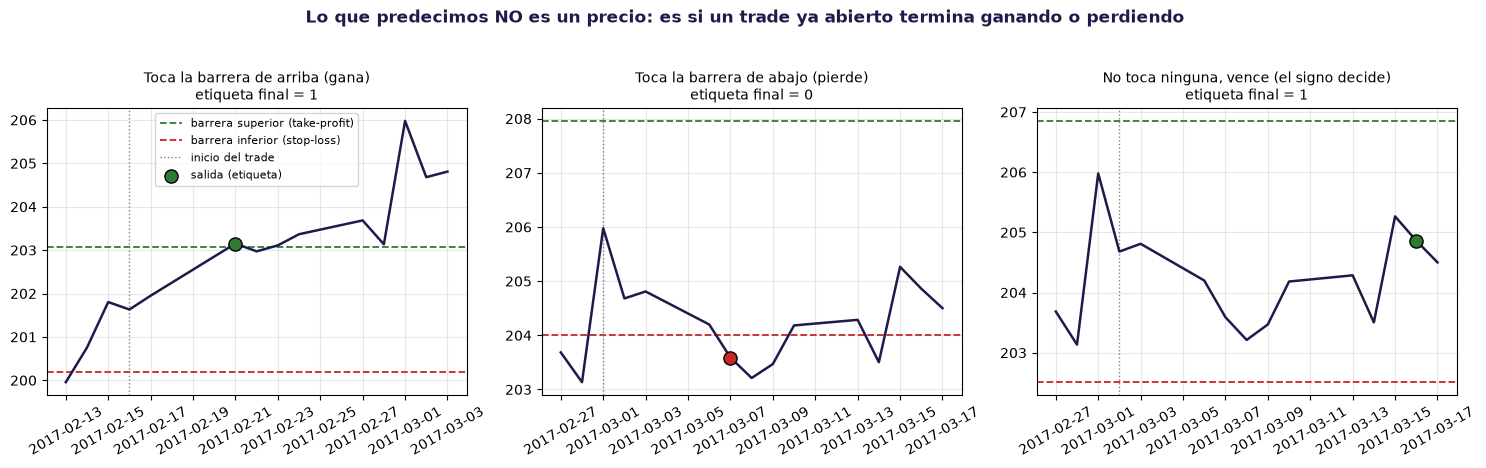

In [4]:
# ── FIGURA: tres ejemplos reales, uno de cada tipo de salida ──────────────────
ejemplos = {}
nombres = {'tp': 'Toca la barrera de arriba (gana)', 'sl': 'Toca la barrera de abajo (pierde)',
           'vencimiento': 'No toca ninguna, vence (el signo decide)'}
for f, (l, fin, motivo) in etiquetas.items():
    if nombres[motivo] not in ejemplos:
        ejemplos[nombres[motivo]] = (f, l, fin)
    if len(ejemplos) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (titulo, (f, l, fin)) in zip(axes, ejemplos.items()):
    k, max_dias = 2.0, 10
    p0, sigma_t = spy.loc[f], float(sigma.loc[f])
    sup, inf = p0*(1+k*sigma_t), p0*(1-k*sigma_t)
    tramo = spy.loc[f - pd.Timedelta(days=3): f + pd.Timedelta(days=max_dias+7)]
    ax.plot(tramo.index, tramo.values, color=NAVY, lw=1.8, zorder=3)
    ax.axhline(sup, color=GREEN, ls='--', lw=1.3, label='barrera superior (take-profit)')
    ax.axhline(inf, color=RED, ls='--', lw=1.3, label='barrera inferior (stop-loss)')
    ax.axvline(f, color='0.5', lw=1, ls=':', label='inicio del trade')
    color_exit = GREEN if l == 1 else RED
    ax.scatter([fin], [spy.loc[fin]], color=color_exit, s=90, zorder=5, edgecolor='k', label='salida (etiqueta)')
    ax.set_title(f'{titulo}\netiqueta final = {l}', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Lo que predecimos NO es un precio: es si un trade ya abierto termina ganando o perdiendo',
             fontweight='bold', color=NAVY, y=1.03)
plt.tight_layout(); plt.show()

**Ahora, las features.** Para cada trade, le damos al modelo 6 números que describen "el clima
del mercado" en el momento exacto en que entró (todos calculados con información hasta ESE día,
nunca después):

| feature | qué mide |
|---|---|
| `vol_20` | volatilidad reciente (EWMA de 20 días) |
| `vol_ratio` | esa volatilidad, relativa a su propio promedio de 100 días — ¿régimen alto o bajo? |
| `mom_5` | momentum de 5 días (suma de retornos) |
| `mom_20` | momentum de 20 días |
| `rsi` | fuerza relativa simplificada (RSI) |
| `dist_sma` | cuán "estirado" está el precio respecto de su media de 100 días |

In [5]:
# ── Las 6 features, calculadas al momento de CADA evento ──────────────────────
delta = r.rolling(14).apply(lambda x: x[x > 0].sum() / (abs(x).sum() + 1e-12))
X_all = pd.DataFrame({
    'vol_20':    sigma,
    'vol_ratio': sigma / sigma.rolling(100).mean(),
    'mom_5':     r.rolling(5).sum(),
    'mom_20':    r.rolling(20).sum(),
    'rsi':       delta,
    'dist_sma':  spy/sma100 - 1,
}).dropna()

lab = pd.Series({k: v[0] for k, v in etiquetas.items()}).sort_index()
fin_ventana = pd.Series({k: v[1] for k, v in etiquetas.items()}).sort_index()
comunes = lab.index.intersection(X_all.index)
X, y = X_all.loc[comunes], lab.loc[comunes]
fin_v = fin_ventana.loc[comunes]
print(f'Dataset final: {len(X)} eventos × {X.shape[1]} features. y=1 ("gana") el {y.mean()*100:.0f}% de las veces.')

Dataset final: 1916 eventos × 6 features. y=1 ("gana") el 60% de las veces.


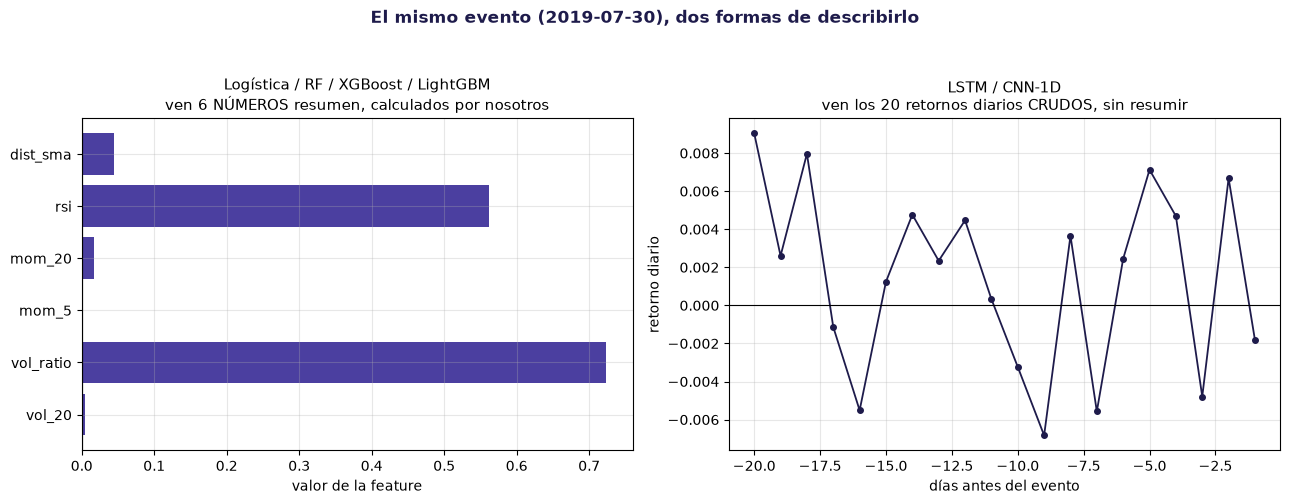

In [6]:
# ── FIGURA: no todos los modelos ven lo mismo ──────────────────────────────────
SEQ_LEN = 20
r_vals = r.values.astype(np.float32)
r_pad = np.concatenate([np.zeros(SEQ_LEN, dtype=np.float32), r_vals])
ventanas_todas = np.lib.stride_tricks.sliding_window_view(r_pad, SEQ_LEN)[:len(r_vals)]

def construir_secuencias(indice_fechas):
    """Para cada fecha, los SEQ_LEN retornos diarios ANTERIORES (walk-forward real)."""
    pos = r.index.get_indexer(indice_fechas)
    return ventanas_todas[pos]

evento_ejemplo = X.index[500]
feats_ejemplo = X.loc[evento_ejemplo]
seq_ejemplo = construir_secuencias([evento_ejemplo])[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].barh(list(X.columns), feats_ejemplo.values, color=VIOLET)
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_title('Logística / RF / XGBoost / LightGBM\nven 6 NÚMEROS resumen, calculados por nosotros', fontsize=10.5)
axes[0].set_xlabel('valor de la feature')

axes[1].plot(range(-SEQ_LEN, 0), seq_ejemplo, 'o-', color=NAVY, ms=4, lw=1.3)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_title('LSTM / CNN-1D\nven los 20 retornos diarios CRUDOS, sin resumir', fontsize=10.5)
axes[1].set_xlabel('días antes del evento'); axes[1].set_ylabel('retorno diario')
fig.suptitle(f'El mismo evento ({evento_ejemplo.date()}), dos formas de describirlo', fontweight='bold', color=NAVY, y=1.04)
plt.tight_layout(); plt.show()

> **Para tener presente:** de acá en más, TODOS los modelos reciben exactamente el mismo
> problema — mismos eventos, misma etiqueta (gana/pierde) — la única diferencia es qué tan
> resumida o cruda es la información que les damos de comer.

---
## Parte B · Lo más básico posible: un modelo, tres formas de medirlo

Antes de comparar seis modelos con una validación sofisticada, hagamos lo más simple que existe:
**UN modelo** (regresión logística, la más simple de todas) y midámoslo de **tres formas**, cada
una un escalón menos ingenuo que la anterior. La idea es ver, en cámara lenta y sobre UN solo
modelo, por qué vamos a necesitar toda la maquinaria que viene después.

### Escalón 1 · Un solo split temporal (lo que haría cualquiera al empezar)

Separamos el 70% más viejo para entrenar y el 30% más nuevo para probar, una sola vez. Nada de
cross-validation todavía — es literalmente lo primero que se le ocurre a cualquiera.

In [7]:
corte = int(len(X) * 0.7)
Xtr, Xte = X.iloc[:corte], X.iloc[corte:]
ytr, yte = y.iloc[:corte], y.iloc[corte:]
referencia = max(y.mean(), 1 - y.mean())

modelo_simple = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
modelo_simple.fit(Xtr, ytr)
acc_split_simple = accuracy_score(yte, modelo_simple.predict(Xte))

print(f'A superar (predecir siempre la clase mayoritaria): {referencia:.3f}')
print(f'Accuracy con UN split simple 70/30: {acc_split_simple:.3f}')

A superar (predecir siempre la clase mayoritaria): 0.604
Accuracy con UN split simple 70/30: 0.541


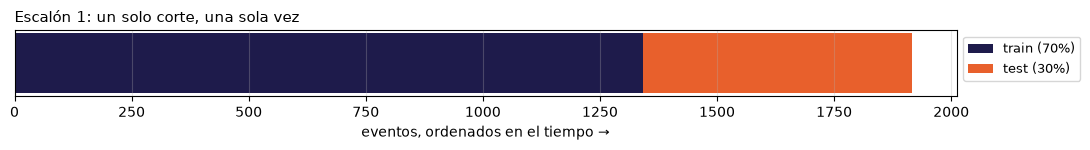

In [8]:
# ── FIGURA: el split más simple posible ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 1.6))
ax.barh([0], [corte], color=NAVY, label='train (70%)')
ax.barh([0], [len(X)-corte], left=corte, color=ORANGE, label='test (30%)')
ax.set_yticks([]); ax.set_xlabel('eventos, ordenados en el tiempo →')
ax.set_title('Escalón 1: un solo corte, una sola vez', fontsize=10.5, loc='left')
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

### Escalón 2 · ¿Un solo split alcanza para confiar en ese número?

Ese 0.3xx de accuracy, ¿es bueno o tuvo suerte con el 30% que le tocó de test? Para no depender
de una sola tirada, la práctica estándar es **Cross-Validation**: partir los datos en 5 pedazos,
rotar cuál hace de test, promediar los 5 resultados. `KFold` de scikit-learn lo hace en una línea
— **barajando** los datos antes de partirlos (`shuffle=True`), como en cualquier problema de ML
que no sea una serie de tiempo.

In [9]:
scores_naive_simple = []
for tr, te in KFold(5, shuffle=True, random_state=0).split(X):
    modelo_simple.fit(X.iloc[tr], y.iloc[tr])
    scores_naive_simple.append(accuracy_score(y.iloc[te], modelo_simple.predict(X.iloc[te])))
scores_naive_simple = np.array(scores_naive_simple)

print(f'Escalón 1 (un split simple):        {acc_split_simple:.3f}')
print(f'Escalón 2 (K-Fold ingenuo, 5 folds): {scores_naive_simple.mean():.3f} ± {scores_naive_simple.std():.3f}')
print('Ya no es un solo número con suerte — es un promedio de 5. Se ve más confiable. ¿Lo es?')

Escalón 1 (un split simple):        0.541
Escalón 2 (K-Fold ingenuo, 5 folds): 0.602 ± 0.009
Ya no es un solo número con suerte — es un promedio de 5. Se ve más confiable. ¿Lo es?


### Escalón 3 · El problema escondido: `shuffle=True` no sabe que esto es una serie de tiempo

`KFold(shuffle=True)` reparte los eventos AL AZAR entre train y test, sin mirar la fecha. El
problema: nuestras etiquetas tienen una ventana `[inicio, fin]` de hasta 10 días (la triple
barrera). Si un evento de TRAIN se solapa en el tiempo con uno de TEST, el modelo puede estar
"espiando" información del futuro del test sin que nadie se dé cuenta. La cura se llama
**purged K-fold + embargo**: el test es un bloque CONTIGUO en el tiempo, y se descarta (purga)
todo evento de train cuya ventana lo toque.

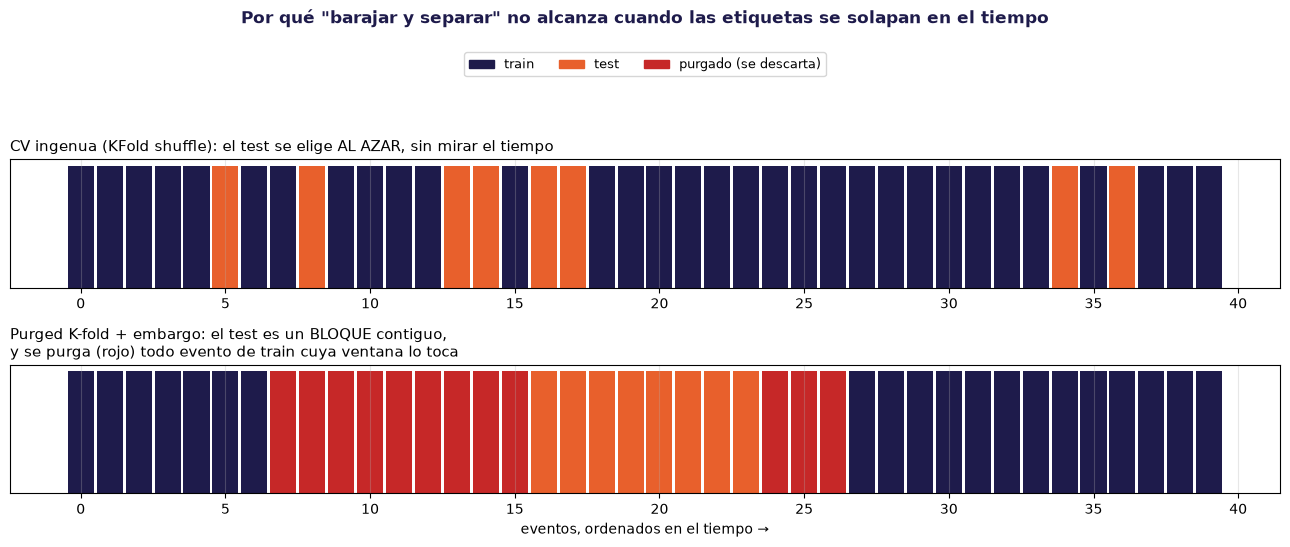

In [10]:
# ── FIGURA: por qué "barajar y separar" no alcanza acá ─────────────────────────
n_demo = 40
X_demo, fin_demo = X.iloc[:n_demo], fin_v.iloc[:n_demo]

kf = KFold(5, shuffle=True, random_state=0)
test_naive = list(kf.split(X_demo))[2][1]

k_folds, embargo_dias, i_fold = 5, 5, 2
indices = np.arange(n_demo)
bordes = np.linspace(0, n_demo, k_folds + 1).astype(int)
test_idx = indices[bordes[i_fold]:bordes[i_fold + 1]]
t0, t1 = X_demo.index[test_idx[0]], X_demo.index[test_idx[-1]]
emb = pd.Timedelta(days=embargo_dias)
purga = (fin_demo.values >= np.datetime64(t0 - emb)) & (X_demo.index.values <= np.datetime64(t1 + emb))
train_mask = np.ones(n_demo, dtype=bool); train_mask[test_idx] = False
purgado_mask = train_mask & purga

fig, axes = plt.subplots(2, 1, figsize=(13, 4.6))
colores_naive = np.where(np.isin(indices, test_naive), ORANGE, NAVY)
axes[0].bar(indices, np.ones(n_demo), color=colores_naive, width=0.9)
axes[0].set_title('CV ingenua (KFold shuffle): el test se elige AL AZAR, sin mirar el tiempo', fontsize=10.5, loc='left')
axes[0].set_yticks([])

colores_purga = np.array([NAVY]*n_demo, dtype=object)
for i in range(n_demo):
    if i in test_idx: colores_purga[i] = ORANGE
    elif purgado_mask[i]: colores_purga[i] = RED
axes[1].bar(indices, np.ones(n_demo), color=list(colores_purga), width=0.9)
axes[1].set_title('Purged K-fold + embargo: el test es un BLOQUE contiguo,\ny se purga (rojo) todo evento de train cuya ventana lo toca', fontsize=10.5, loc='left')
axes[1].set_yticks([]); axes[1].set_xlabel('eventos, ordenados en el tiempo →')

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=NAVY, label='train'), Patch(color=ORANGE, label='test'),
                     Patch(color=RED, label='purgado (se descarta)')],
           loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.1))
fig.suptitle('Por qué "barajar y separar" no alcanza cuando las etiquetas se solapan en el tiempo',
             fontweight='bold', color=NAVY, y=1.18)
plt.tight_layout(); plt.show()

In [11]:
# ── La validación honesta, implementada a mano ─────────────────────────────────
def purged_kfold_scores(X, y, fin_ventana, modelo, k=5, embargo_dias=5, pesos=None):
    """K-fold temporal con purga (por solapamiento de ventanas) y embargo, vectorizado."""
    n = len(X)
    indices = np.arange(n)
    bordes = np.linspace(0, n, k+1).astype(int)
    ini_all, fin_all = X.index.values, fin_ventana.values
    emb = pd.Timedelta(days=embargo_dias)
    scores = []
    for i in range(k):
        test_idx = indices[bordes[i]:bordes[i+1]]
        t0, t1 = X.index[test_idx[0]], X.index[test_idx[-1]]
        train_mask = np.ones(n, dtype=bool); train_mask[test_idx] = False
        purga = (fin_all >= np.datetime64(t0 - emb)) & (ini_all <= np.datetime64(t1 + emb))
        train_mask &= ~purga
        if pesos is not None:
            modelo.fit(X[train_mask], y[train_mask], sample_weight=pesos.values[train_mask])
        else:
            modelo.fit(X[train_mask], y[train_mask])
        scores.append(accuracy_score(y.iloc[test_idx], modelo.predict(X.iloc[test_idx])))
    return np.array(scores)

In [12]:
scores_purged_simple = purged_kfold_scores(X, y, fin_v, modelo_simple, k=5, embargo_dias=5)

print(f'Escalón 1 (un split simple):         {acc_split_simple:.3f}')
print(f'Escalón 2 (K-Fold ingenuo):           {scores_naive_simple.mean():.3f}')
print(f'Escalón 3 (purged K-fold, honesto):   {scores_purged_simple.mean():.3f}')
print(f'Referencia (clase mayoritaria):           {referencia:.3f}')
print()
print('Dos lecciones distintas, no una sola:')
print(f'  Escalón 1 -> 2: un solo split depende de la suerte del 30% que le tocó de test')
print(f'  ({acc_split_simple:.3f}, un solo número); promediar 5 folds (Escalón 2) saca esa varianza.')
print(f'  Escalón 2 -> 3: pero ESE promedio ({scores_naive_simple.mean():.3f}) está inflado por leakage —')
print(f'  al purgar baja a {scores_purged_simple.mean():.3f}, más cerca del Referencia. Menos varianza no es lo mismo')
print('  que menos sesgo: hacían falta las DOS curas. Ahora escalemos de 1 modelo a 6, con esta MISMA vara.')

Escalón 1 (un split simple):         0.541
Escalón 2 (K-Fold ingenuo):           0.602
Escalón 3 (purged K-fold, honesto):   0.586
Referencia (clase mayoritaria):           0.604

Dos lecciones distintas, no una sola:
  Escalón 1 -> 2: un solo split depende de la suerte del 30% que le tocó de test
  (0.541, un solo número); promediar 5 folds (Escalón 2) saca esa varianza.
  Escalón 2 -> 3: pero ESE promedio (0.602) está inflado por leakage —
  al purgar baja a 0.586, más cerca del Referencia. Menos varianza no es lo mismo
  que menos sesgo: hacían falta las DOS curas. Ahora escalemos de 1 modelo a 6, con esta MISMA vara.


---
## Ejercicio 1 · Seis modelos, la misma pregunta

Le hacemos la MISMA pregunta ("¿este trade gana o pierde?") a seis modelos, de lo más simple a
lo más flexible:

| modelo | en una frase | qué le damos de comer |
|---|---|---|
| **Logística** | una línea recta que separa "gana" de "pierde" | las 6 features |
| **Random Forest** | cientos de árboles, cada uno mira una versión al azar de los datos, VOTAN | las 6 features |
| **XGBoost** | árboles EN CADENA, cada uno corrige el error del anterior | las 6 features |
| **LightGBM** | el mismo XGBoost, pero los árboles crecen distinto (más rápido) | las 6 features |
| **LSTM** | una red que "lee" la secuencia día por día y decide qué recordar | los 20 retornos crudos |
| **CNN-1D** | una red que detecta patrones locales en la secuencia | los 20 retornos crudos |

**La pregunta del ejercicio no es "cuál da el número más alto".** Es la misma que ya vimos en
la Parte B con UN modelo — ¿ese número más alto es señal real, o es el modelo aprovechando el
leakage del `KFold` ingenuo? — pero ahora escalada a seis modelos de complejidad creciente,
para ver si la maquinaria extra (más árboles, más parámetros, redes enteras) ayuda o empeora
el problema. Medimos TODO dos veces, con la MISMA función `purged_kfold_scores` de la Parte B.

In [13]:
# ── Las dos redes: LSTM y CNN-1D, sobre la secuencia cruda de retornos ─────────
import torch, torch.nn as nn

if HAY_XGB:
    boost = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=0, verbosity=0)
else:
    boost = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=0)

try:
    from lightgbm import LGBMClassifier
    lgbm = LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, verbosity=-1)
    HAY_LGBM = True
except ImportError:
    lgbm = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=0)
    HAY_LGBM = False

class RedSecuencial:
    """Wrapper sklearn-compatible (.fit/.predict) para una red de PyTorch chiquita.
    Ignora las 6 features: usa X.index para reconstruir la secuencia cruda de retornos."""
    def __init__(self, kind='lstm', hidden=16, epochs=40, lr=5e-3, seed=0):
        self.kind, self.hidden, self.epochs, self.lr, self.seed = kind, hidden, epochs, lr, seed
    def _armar_red(self):
        torch.manual_seed(self.seed)
        if self.kind == 'lstm':
            self.core = nn.LSTM(input_size=1, hidden_size=self.hidden, batch_first=True)
            self.head = nn.Linear(self.hidden, 1)
        else:
            self.core = nn.Sequential(nn.Conv1d(1, self.hidden, 3, padding=1), nn.ReLU(),
                                       nn.Conv1d(self.hidden, self.hidden, 3, padding=1), nn.ReLU(),
                                       nn.AdaptiveAvgPool1d(1))
            self.head = nn.Linear(self.hidden, 1)
    def _forward(self, Xs):
        if self.kind == 'lstm':
            _, (hN, _) = self.core(Xs); return self.head(hN[-1]).squeeze(-1)
        z = self.core(Xs.transpose(1, 2)).squeeze(-1); return self.head(z).squeeze(-1)
    def fit(self, X, y):
        self._armar_red()
        Xs = torch.tensor(construir_secuencias(X.index)).unsqueeze(-1)
        ys = torch.tensor(y.values, dtype=torch.float32)
        opt = torch.optim.Adam(list(self.core.parameters())+list(self.head.parameters()), lr=self.lr, weight_decay=1e-4)
        lossf = nn.BCEWithLogitsLoss()
        for _ in range(self.epochs):
            opt.zero_grad(); loss = lossf(self._forward(Xs), ys); loss.backward(); opt.step()
        return self
    def predict(self, X):
        Xs = torch.tensor(construir_secuencias(X.index)).unsqueeze(-1)
        with torch.no_grad(): proba = torch.sigmoid(self._forward(Xs))
        return (proba.numpy() > 0.5).astype(int)

modelos5 = {
    'Logística':      make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    'Random forest':  RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0),
    'XGBoost' if HAY_XGB else 'GradBoosting': boost,
    'LightGBM' if HAY_LGBM else 'GradBoosting2': lgbm,
    'LSTM':           RedSecuencial(kind='lstm'),
    'CNN-1D':         RedSecuencial(kind='cnn'),
}
print('Seis modelos armados.')

Seis modelos armados.


In [14]:
# ── Correr los seis, con CV ingenua Y con purged CV ────────────────────────────
print(f'{"modelo":<16}{"CV ingenua":>12}{"purged CV":>12}{"inflación":>12}')
resultados5 = {}
for nombre, m in modelos5.items():
    naive_m = []
    for tr, te in KFold(5, shuffle=True, random_state=0).split(X):
        m.fit(X.iloc[tr], y.iloc[tr])
        naive_m.append(accuracy_score(y.iloc[te], m.predict(X.iloc[te])))
    purg_m = purged_kfold_scores(X, y, fin_v, m, k=5, embargo_dias=5)
    resultados5[nombre] = (np.mean(naive_m), purg_m.mean())
    print(f'{nombre:<16}{np.mean(naive_m):>12.3f}{purg_m.mean():>12.3f}{(np.mean(naive_m)-purg_m.mean())*100:>+11.1f}pp')

print(f'\nReferencia: {referencia:.3f}. La CV ingenua premia la CAPACIDAD DE MEMORIZAR, no la señal real.')

modelo            CV ingenua   purged CV   inflación
Logística              0.602       0.586       +1.6pp
Random forest          0.633       0.543       +9.0pp
XGBoost                0.664       0.503      +16.1pp
LightGBM               0.671       0.503      +16.8pp
LSTM                   0.604       0.604       -0.0pp
CNN-1D                 0.604       0.604       -0.0pp

Referencia: 0.604. La CV ingenua premia la CAPACIDAD DE MEMORIZAR, no la señal real.


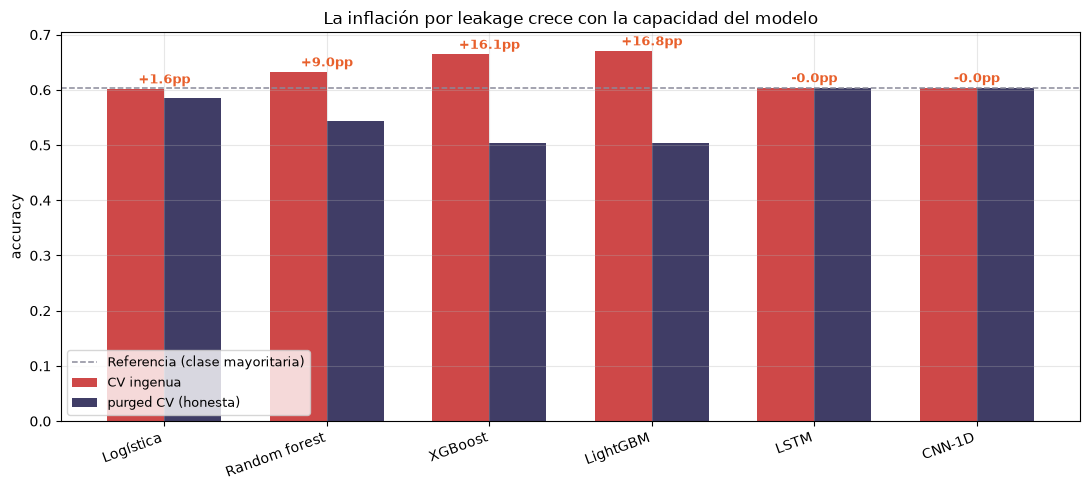

In [15]:
# ── FIGURA: la inflación crece con la capacidad del modelo ─────────────────────
nombres5 = list(resultados5.keys())
naive_v = [resultados5[n][0] for n in nombres5]
purg_v  = [resultados5[n][1] for n in nombres5]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(nombres5)); w = 0.35
ax.bar(x - w/2, naive_v, width=w, color=RED, alpha=0.85, label='CV ingenua')
ax.bar(x + w/2, purg_v, width=w, color=NAVY, alpha=0.85, label='purged CV (honesta)')
ax.axhline(referencia, color='#8A8A9A', ls='--', lw=1.1, label='Referencia (clase mayoritaria)')
for i, (nv, pv) in enumerate(zip(naive_v, purg_v)):
    ax.annotate(f'{(nv-pv)*100:+.1f}pp', (x[i], max(nv, pv) + 0.01), ha='center', fontsize=9, color=ORANGE, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(nombres5, rotation=20, ha='right')
ax.set_ylabel('accuracy'); ax.set_title('La inflación por leakage crece con la capacidad del modelo')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Concretando: ¿qué predijeron, en un fold real?** Tomamos el último bloque de test (purgado)
y miramos, caso por caso, qué dijeron Random Forest y LSTM contra lo que realmente pasó.

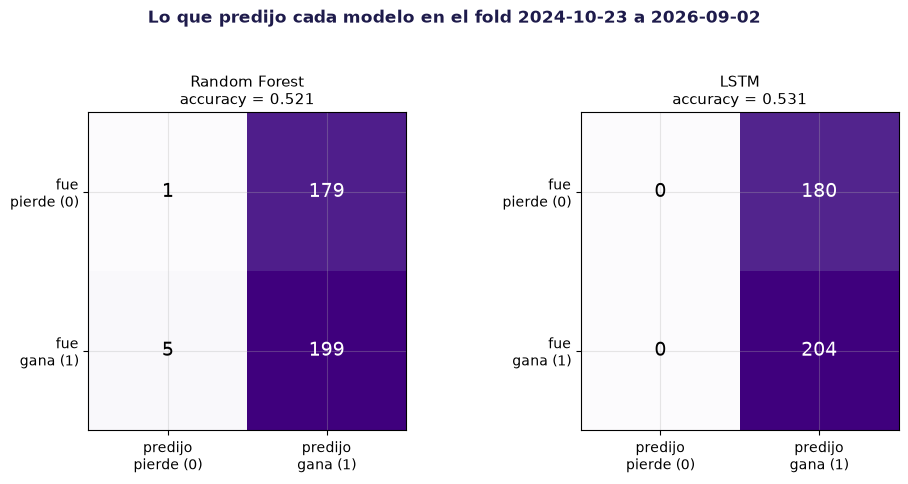

In [16]:
# ── FIGURA: matriz de confusión, en un fold de test real y purgado ─────────────
n = len(X); k = 5
bordes = np.linspace(0, n, k+1).astype(int)
i_fold = 4
test_idx = np.arange(n)[bordes[i_fold]:bordes[i_fold+1]]
t0, t1 = X.index[test_idx[0]], X.index[test_idx[-1]]
emb = pd.Timedelta(days=5)
train_mask = np.ones(n, dtype=bool); train_mask[test_idx] = False
purga = (fin_v.values >= np.datetime64(t0-emb)) & (X.index.values <= np.datetime64(t1+emb))
train_mask &= ~purga

rf_ej = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0).fit(X[train_mask], y[train_mask])
lstm_ej = RedSecuencial(kind='lstm').fit(X[train_mask], y[train_mask])
pred_rf, pred_lstm = rf_ej.predict(X.iloc[test_idx]), lstm_ej.predict(X.iloc[test_idx])
y_test = y.iloc[test_idx].values

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, pred, nombre in zip(axes, [pred_rf, pred_lstm], ['Random Forest', 'LSTM']):
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    ax.imshow(cm, cmap='Purples')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['predijo\npierde (0)', 'predijo\ngana (1)'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['fue\npierde (0)', 'fue\ngana (1)'])
    ax.set_title(f'{nombre}\naccuracy = {(cm.trace()/cm.sum()):.3f}', fontsize=10.5)
fig.suptitle(f'Lo que predijo cada modelo en el fold {t0.date()} a {t1.date()}', fontweight='bold', color=NAVY, y=1.04)
plt.tight_layout(); plt.show()

In [17]:
# ── Matrices de confusión de RF y LSTM en los 5 folds ──────────────────────────
# Esto muestra POR QUÉ el promedio de RF (0.541) es menor que el de LSTM (0.606):
# en cada fold, LSTM predijo "gana" siempre; RF intentó predecir "pierde" y se equivocó.

print(f'{"="*62}')
for i_fold in range(5):
    test_idx_ = np.arange(len(X))[bordes[i_fold]:bordes[i_fold+1]]
    t0_, t1_  = X.index[test_idx_[0]], X.index[test_idx_[-1]]
    train_mask_ = np.ones(len(X), dtype=bool); train_mask_[test_idx_] = False
    purga_ = (fin_v.values >= np.datetime64(t0_ - emb)) & (X.index.values <= np.datetime64(t1_ + emb))
    train_mask_ &= ~purga_

    rf_f    = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0).fit(X[train_mask_], y[train_mask_])
    lstm_f  = RedSecuencial(kind='lstm').fit(X[train_mask_], y[train_mask_])
    pred_rf_f   = rf_f.predict(X.iloc[test_idx_])
    pred_lstm_f = lstm_f.predict(X.iloc[test_idx_])
    y_f = y.iloc[test_idx_].values

    cm_rf_f   = confusion_matrix(y_f, pred_rf_f,   labels=[0,1])
    cm_lstm_f = confusion_matrix(y_f, pred_lstm_f, labels=[0,1])
    referencia_f  = max(y_f.mean(), 1 - y_f.mean())

    print(f'FOLD {i_fold+1}  ({t0_.date()} → {t1_.date()})   Referencia={referencia_f:.3f}')
    print(f'{"─"*62}')
    print(f'              predijo PIERDE   predijo GANA')
    print(f'RF   fue P:   {cm_rf_f[0,0]:>6}           {cm_rf_f[0,1]:>6}')
    print(f'     fue G:   {cm_rf_f[1,0]:>6}           {cm_rf_f[1,1]:>6}    acc={accuracy_score(y_f, pred_rf_f):.3f}')
    print(f'LSTM fue P:   {cm_lstm_f[0,0]:>6}           {cm_lstm_f[0,1]:>6}')
    print(f'     fue G:   {cm_lstm_f[1,0]:>6}           {cm_lstm_f[1,1]:>6}    acc={accuracy_score(y_f, pred_lstm_f):.3f}')
    print(f'RF predijo "pierde": {(pred_rf_f==0).sum()} veces | LSTM: {(pred_lstm_f==0).sum()} veces')
    print(f'{"="*62}')

FOLD 1  (2017-02-21 → 2018-10-19)   Referencia=0.642
──────────────────────────────────────────────────────────────
              predijo PIERDE   predijo GANA
RF   fue P:       81               56
     fue G:      155               91    acc=0.449
LSTM fue P:        0              137
     fue G:        0              246    acc=0.642
RF predijo "pierde": 236 veces | LSTM: 0 veces
FOLD 2  (2018-10-22 → 2020-11-16)   Referencia=0.642
──────────────────────────────────────────────────────────────
              predijo PIERDE   predijo GANA
RF   fue P:       17              120
     fue G:       38              208    acc=0.587
LSTM fue P:        0              137
     fue G:        0              246    acc=0.642
RF predijo "pierde": 55 veces | LSTM: 0 veces
FOLD 3  (2020-11-17 → 2023-02-21)   Referencia=0.569
──────────────────────────────────────────────────────────────
              predijo PIERDE   predijo GANA
RF   fue P:       33              132
     fue G:       25             

---
## Ejercicio 2 · ¿Las técnicas de López de Prado mejoran al modelo?

El Ejercicio 1 ya fija la validación honesta (purged CV). Ahora la pregunta cambia: **con esa
validación fija, ¿el ETIQUETADO y el PESADO de cada muestra hacen alguna diferencia real?**

Comparamos tres formas de armar el mismo problema, con el MISMO modelo (Random Forest) y la
MISMA validación (purged K-fold):

| pipeline | etiqueta | peso de cada muestra |
|---|---|---|
| **1 · Ingenuo** | horizonte fijo (¿subió en 10 días? sí/no, sin barreras) | todas pesan igual |
| **2 · Etiqueta LDP, sin pesos** | triple barrera (la del Ejercicio 1) | todas pesan igual |
| **3 · LDP completo** | triple barrera | por **unicidad**: pesa menos el evento que comparte ventana con muchos otros |

**¿Por qué pesar distinto?** Si dos trades se abrieron casi el mismo día y sus ventanas de 10 días
se solapan, no son dos observaciones independientes — son casi la misma observación contada dos
veces. La figura de abajo lo muestra con eventos reales.

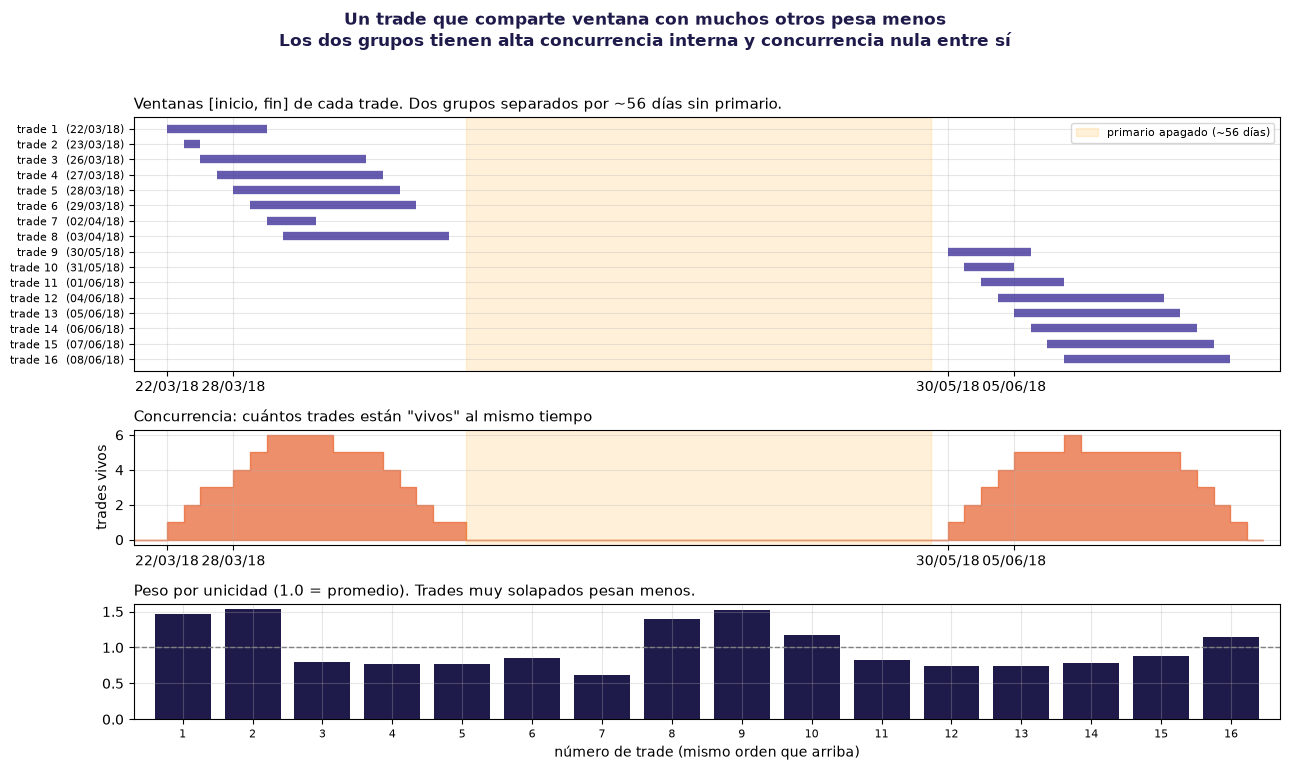

Pesos: mín=0.61  máx=1.53  media=1.00
Período: 2018-03-22 → 2018-06-08


In [18]:
# ── FIGURA: qué significa "pesar por unicidad" ──────────────────────────────────
# Usamos un período con un gap real (primario apagado ~56 días en 2018):
# 8 eventos antes del gap + 8 eventos después → dos grupos claramente separados.

def pesos_por_unicidad(ini, fin):
    pos_ini = r.index.get_indexer(ini)
    pos_fin = r.index.get_indexer(fin)
    n_dias = len(r.index)
    delta_ = np.zeros(n_dias + 1)
    np.add.at(delta_, pos_ini, 1)
    np.add.at(delta_, pos_fin + 1, -1)
    concurrencia = np.cumsum(delta_[:-1])
    inv_conc = np.divide(1.0, concurrencia, out=np.zeros_like(concurrencia), where=concurrencia > 0)
    cum_inv = np.concatenate([[0.0], np.cumsum(inv_conc)])
    suma_ventana = cum_inv[pos_fin + 1] - cum_inv[pos_ini]
    largo_ventana = (pos_fin - pos_ini + 1)
    u = suma_ventana / largo_ventana
    pesos = pd.Series(u, index=ini)
    return pesos * len(pesos) / pesos.sum(), concurrencia

# Selección de eventos: 8 antes del gap + 8 después
gaps_idx = pd.Series([(X.index[i+1]-X.index[i]).days for i in range(len(X)-1)], index=X.index[:-1])
pos_gap = X.index.get_loc(gaps_idx[gaps_idx > 50].index[0])
idx_demo_sel = list(range(pos_gap-8, pos_gap)) + list(range(pos_gap+1, pos_gap+9))
X_d2   = X.iloc[idx_demo_sel]
fin_d2 = fin_v.iloc[idx_demo_sel]
n_demo2 = len(X_d2)

pesos_demo, conc_full = pesos_por_unicidad(X_d2.index, fin_d2)
pos_ini_d = r.index.get_indexer(X_d2.index)
pos_fin_d = r.index.get_indexer(fin_d2)

# Posiciones relativas (t_ini = 0) para que los paneles 1 y 2 arranquen desde 0
t_ini = pos_ini_d.min() - 2
t_fin = pos_fin_d.max() + 3
pos_ini_rel = pos_ini_d - t_ini
pos_fin_rel  = pos_fin_d  - t_ini
eje_rel = np.arange(0, t_fin - t_ini)

# Etiquetas de fechas en el eje X de los paneles 1 y 2
tick_pos  = pos_ini_rel[::4]
tick_labs = [X_d2.index[i].strftime('%d/%m/%y') for i in range(0, n_demo2, 4)]

fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), gridspec_kw={'height_ratios': [2.2, 1, 1]})

# Panel 1: ventanas de los trades
for i, (pi, pf) in enumerate(zip(pos_ini_rel, pos_fin_rel)):
    axes[0].plot([pi, pf], [i, i], lw=6, solid_capstyle='butt', color=VIOLET, alpha=0.85)
axes[0].set_yticks(range(n_demo2))
axes[0].set_yticklabels([f'trade {i+1}  ({X_d2.index[i].strftime("%d/%m/%y")})' for i in range(n_demo2)], fontsize=8)
axes[0].set_title('Ventanas [inicio, fin] de cada trade. Dos grupos separados por ~56 días sin primario.', fontsize=10.5, loc='left')
axes[0].invert_yaxis()
gap_left  = pos_fin_rel[7] + 1
gap_right = pos_ini_rel[8] - 1
axes[0].axvspan(gap_left, gap_right, color='orange', alpha=0.15, label='primario apagado (~56 días)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xticks(tick_pos); axes[0].set_xticklabels(tick_labs)
axes[0].set_xlim(0, t_fin - t_ini)

# Panel 2: concurrencia (comparte eje X con panel 1)
axes[1].fill_between(eje_rel, conc_full[t_ini:t_fin], step='post', color=ORANGE, alpha=0.7)
axes[1].set_title('Concurrencia: cuántos trades están "vivos" al mismo tiempo', fontsize=10.5, loc='left')
axes[1].set_ylabel('trades vivos')
axes[1].axvspan(gap_left, gap_right, color='orange', alpha=0.15)
axes[1].set_xticks(tick_pos); axes[1].set_xticklabels(tick_labs)
axes[1].set_xlim(0, t_fin - t_ini)

# Panel 3: pesos por trade (eje X propio: número de trade)
axes[2].bar(range(n_demo2), pesos_demo.values, color=NAVY)
axes[2].axhline(1.0, color='0.5', ls='--', lw=1)
axes[2].set_xticks(range(n_demo2))
axes[2].set_xticklabels([str(i+1) for i in range(n_demo2)], fontsize=8)
axes[2].set_xlim(-0.7, n_demo2 - 0.3)
axes[2].set_title('Peso por unicidad (1.0 = promedio). Trades muy solapados pesan menos.', fontsize=10.5, loc='left')
axes[2].set_xlabel('número de trade (mismo orden que arriba)')

fig.suptitle('Un trade que comparte ventana con muchos otros pesa menos\n'
             'Los dos grupos tienen alta concurrencia interna y concurrencia nula entre sí',
             fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

print(f'Pesos: mín={pesos_demo.min():.2f}  máx={pesos_demo.max():.2f}  media={pesos_demo.mean():.2f}')
print(f'Período: {X_d2.index[0].date()} → {X_d2.index[-1].date()}')

In [19]:
# ── Pipeline 1: etiqueta ingenua, horizonte fijo (sin barreras dinámicas) ─────
HORIZ = 10
pos_evento = spy.index.get_indexer(X.index)
pos_fin_horiz = np.minimum(pos_evento + HORIZ, len(spy.index) - 1)
y_ingenuo = pd.Series((spy.values[pos_fin_horiz] > spy.values[pos_evento]).astype(int), index=X.index)
fin_ingenuo = pd.Series(spy.index.values[pos_fin_horiz], index=X.index)

# ── Pipeline 3: pesos por unicidad sobre TODO el dataset ───────────────────────
pesos_LDP, _ = pesos_por_unicidad(X.index, fin_v)
print(f'Pesos por unicidad: van de {pesos_LDP.min():.2f} (muy solapado) a {pesos_LDP.max():.2f} (único), media {pesos_LDP.mean():.2f}')

pipelines = {
    '1 - Ingenuo (horizonte fijo)':         dict(y=y_ingenuo, fin=fin_ingenuo, pesos=None),
    '2 - Triple barrera, sin pesos':        dict(y=y,         fin=fin_v,       pesos=None),
    '3 - Triple barrera + unicidad (LDP)': dict(y=y,         fin=fin_v,       pesos=pesos_LDP),
}

print(f'\n{"pipeline":<40}{"Referencia":>9}{"accuracy":>11}{"edge":>9}')
resultados6 = {}
for nombre, cfg in pipelines.items():
    rf6 = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0)
    sc = purged_kfold_scores(X, cfg['y'], cfg['fin'], rf6, k=5, embargo_dias=5, pesos=cfg['pesos'])
    referencia_p = max(cfg['y'].mean(), 1 - cfg['y'].mean())
    resultados6[nombre] = (referencia_p, sc.mean(), sc.mean() - referencia_p)
    print(f'{nombre:<40}{referencia_p:>9.3f}{sc.mean():>11.3f}{(sc.mean()-referencia_p)*100:>+8.1f}pp')

print('\nComparamos el EDGE (accuracy − Referencia propio de cada pipeline), porque cada etiqueta')
print('tiene su propia tasa de clase mayoritaria — el accuracy crudo no es comparable entre ellas.')

Pesos por unicidad: van de 0.57 (muy solapado) a 5.47 (único), media 1.00

pipeline                                Referencia   accuracy     edge
1 - Ingenuo (horizonte fijo)                0.654      0.602    -5.2pp
2 - Triple barrera, sin pesos               0.604      0.543    -6.1pp
3 - Triple barrera + unicidad (LDP)         0.604      0.553    -5.1pp

Comparamos el EDGE (accuracy − Referencia propio de cada pipeline), porque cada etiqueta
tiene su propia tasa de clase mayoritaria — el accuracy crudo no es comparable entre ellas.


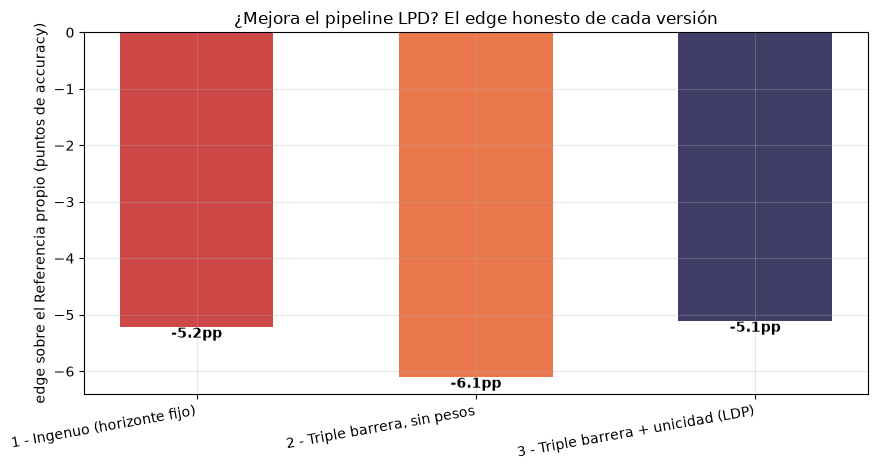

In [20]:
# ── FIGURA: el edge de cada pipeline sobre su propio Referencia ───────────────────
nombres6 = list(resultados6.keys())
edges6 = [resultados6[n][2] * 100 for n in nombres6]
colores6 = [RED, ORANGE, NAVY]

fig, ax = plt.subplots(figsize=(9, 4.8))
barras = ax.bar(nombres6, edges6, color=colores6, alpha=0.85, width=0.55)
ax.axhline(0, color='k', lw=1.2)
for b, v in zip(barras, edges6):
    ax.annotate(f'{v:+.1f}pp', (b.get_x() + b.get_width()/2, v), ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=10, fontweight='bold')
ax.set_ylabel('edge sobre el Referencia propio (puntos de accuracy)')
ax.set_xticks(range(len(nombres6))); ax.set_xticklabels(nombres6, rotation=10, ha='right')
ax.set_title('¿Mejora el pipeline LPD? El edge honesto de cada versión')
plt.tight_layout(); plt.show()